# 1. ENVIRONMENT SETUP AND IMPORTS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


# 2. DATA LOADING AND INITIAL EXPLORATION

In [3]:
users_df = pd.read_csv('../data/users.csv')
flights_df = pd.read_csv('../data/flights.csv')
hotels_df = pd.read_csv('../data/hotels.csv')

print("Dataset Shapes:")
print(f"Users: {users_df.shape}")
print(f"Flights: {flights_df.shape}")
print(f"Hotels: {hotels_df.shape}")

# Display first few rows
print("\n" + "="*80)
print("FLIGHTS DATASET - First 5 Rows")
print("="*80)
print(flights_df.head())

print("\n" + "="*80)
print("FLIGHTS DATASET - Info")
print("="*80)
print(flights_df.info())

print("\n" + "="*80)
print("FLIGHTS DATASET - Statistical Summary")
print("="*80)
print(flights_df.describe())

Dataset Shapes:
Users: (1340, 5)
Flights: (271888, 10)
Hotels: (40552, 8)

FLIGHTS DATASET - First 5 Rows
   travelCode  userCode                from                  to  flightType  \
0           0         0         Recife (PE)  Florianopolis (SC)  firstClass   
1           0         0  Florianopolis (SC)         Recife (PE)  firstClass   
2           1         0       Brasilia (DF)  Florianopolis (SC)  firstClass   
3           1         0  Florianopolis (SC)       Brasilia (DF)  firstClass   
4           2         0        Aracaju (SE)       Salvador (BH)  firstClass   

     price  time  distance       agency        date  
0  1434.38  1.76    676.53  FlyingDrops   9/26/2019  
1  1292.29  1.76    676.53  FlyingDrops   9/30/2019  
2  1487.52  1.66    637.56      CloudFy   10/3/2019  
3  1127.36  1.66    637.56      CloudFy   10/4/2019  
4  1684.05  2.16    830.86      CloudFy  10/10/2019  

FLIGHTS DATASET - Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 

# 3. EXPLORATORY DATA ANALYSIS (EDA)


EXPLORATORY DATA ANALYSIS

Missing Values:
travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

Duplicate Rows: 0

Merged Dataset Shape: (271888, 15)


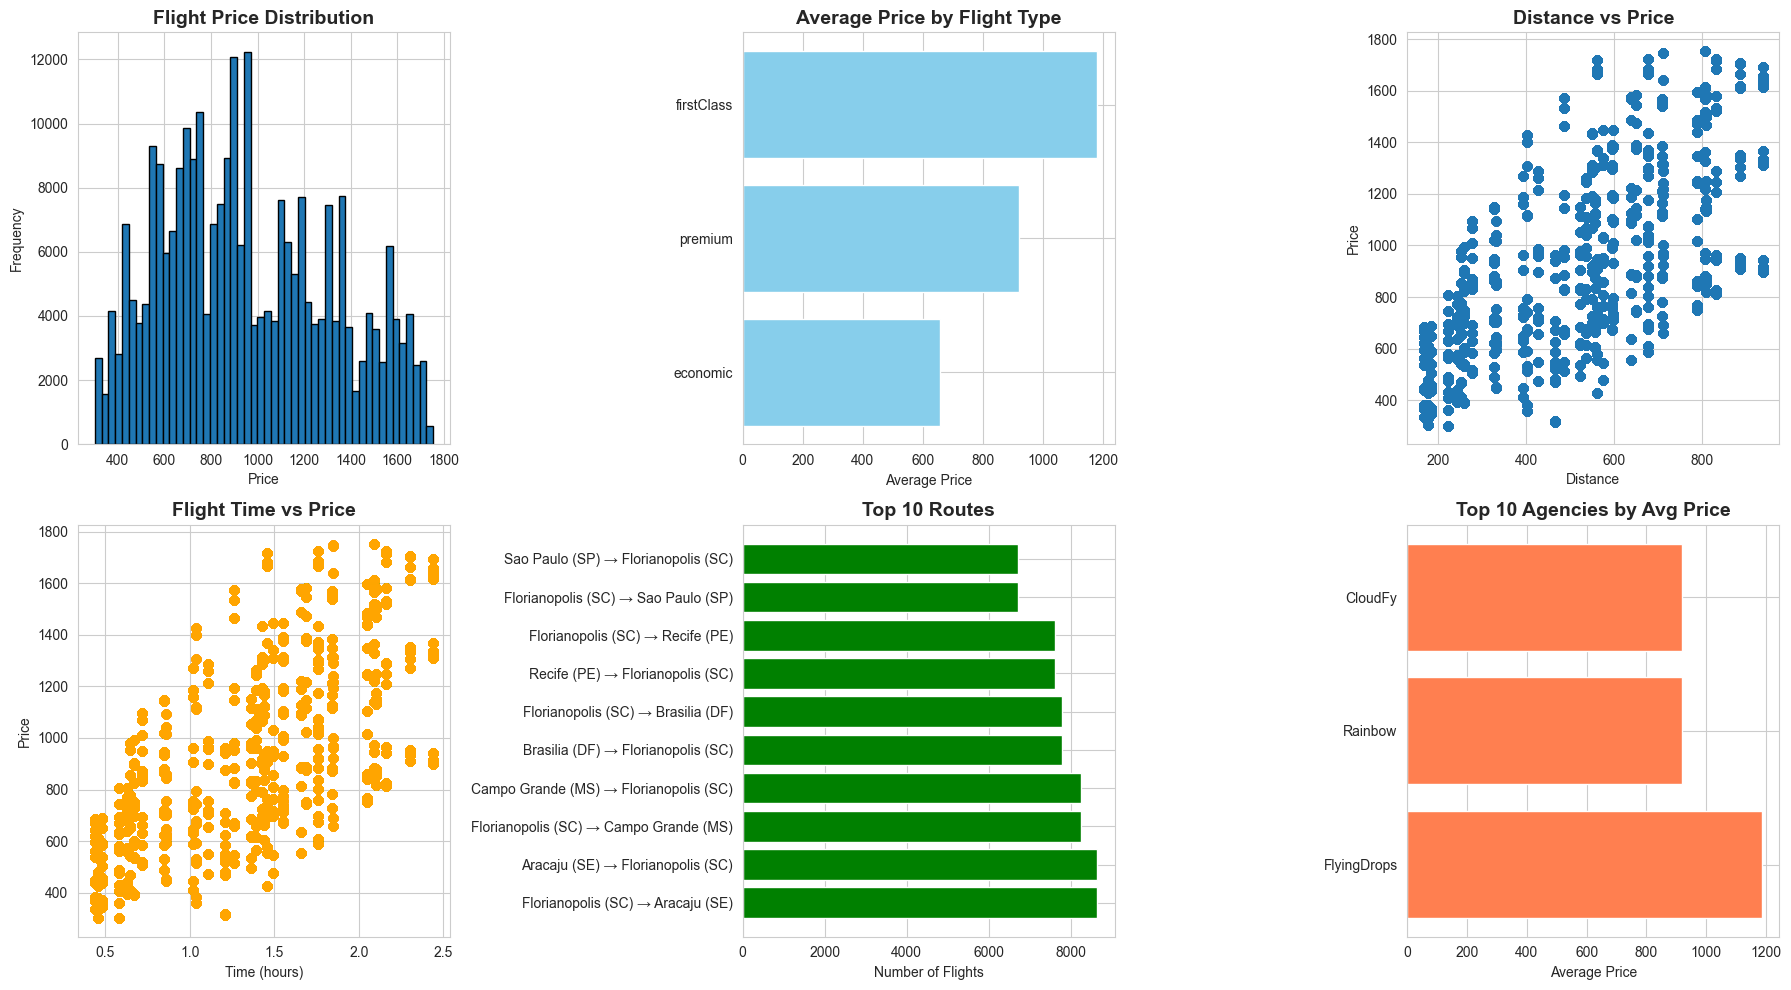


CORRELATION ANALYSIS

Correlation Matrix:
             price     time  distance
price     1.000000  0.64180  0.641915
time      0.641800  1.00000  0.999990
distance  0.641915  0.99999  1.000000


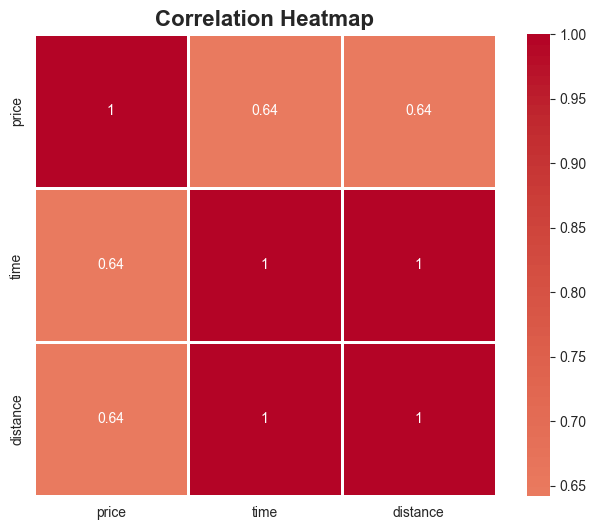

In [4]:
print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# Check for missing values
print("\nMissing Values:")
print(flights_df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate Rows: {flights_df.duplicated().sum()}")

# Merge with users dataset for additional features
flights_with_users = flights_df.merge(users_df, left_on='userCode', right_on='code', how='left')
print(f"\nMerged Dataset Shape: {flights_with_users.shape}")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Price distribution
axes[0, 0].hist(flights_df['price'], bins=50, edgecolor='black')
axes[0, 0].set_title('Flight Price Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Price')
axes[0, 0].set_ylabel('Frequency')

# Price by flight type
flight_type_price = flights_df.groupby('flightType')['price'].mean().sort_values()
axes[0, 1].barh(flight_type_price.index, flight_type_price.values, color='skyblue')
axes[0, 1].set_title('Average Price by Flight Type', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Average Price')

# Distance vs Price
axes[0, 2].scatter(flights_df['distance'], flights_df['price'], alpha=0.5)
axes[0, 2].set_title('Distance vs Price', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Distance')
axes[0, 2].set_ylabel('Price')

# Time vs Price
axes[1, 0].scatter(flights_df['time'], flights_df['price'], alpha=0.5, color='orange')
axes[1, 0].set_title('Flight Time vs Price', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Time (hours)')
axes[1, 0].set_ylabel('Price')

# Top routes
flights_df['route'] = flights_df['from'] + ' → ' + flights_df['to']
top_routes = flights_df['route'].value_counts().head(10)
axes[1, 1].barh(top_routes.index, top_routes.values, color='green')
axes[1, 1].set_title('Top 10 Routes', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Number of Flights')

# Price by agency
agency_price = flights_df.groupby('agency')['price'].mean().sort_values(ascending=False).head(10)
axes[1, 2].barh(agency_price.index, agency_price.values, color='coral')
axes[1, 2].set_title('Top 10 Agencies by Avg Price', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Average Price')

plt.tight_layout()
plt.show()

# Correlation analysis
print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)

# Prepare numeric columns for correlation
flights_numeric = flights_df[['price', 'time', 'distance']].copy()
print("\nCorrelation Matrix:")
print(flights_numeric.corr())

plt.figure(figsize=(8, 6))
sns.heatmap(flights_numeric.corr(), annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

# Feature Engineering

In [5]:
print("\n" + "="*80)
print("FEATURE ENGINEERING (NO DATA LEAKAGE)")
print("="*80)

# Create a copy for feature engineering
df = flights_with_users.copy()

# Extract date features
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Encode categorical variables
label_encoders = {}
categorical_cols = ['from', 'to', 'flightType', 'agency', 'gender', 'company']

for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

#  ONLY create features that DON'T use 'price'
# REMOVE: price_per_km (uses price)
# REMOVE: price_per_hour (uses price)

# Safe derived features
df['speed'] = df['distance'] / (df['time'] + 1)  #  Safe - no price
df['distance_time_ratio'] = df['distance'] / (df['time'] + 0.1)  #  Safe

# Age bins
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 50, 100], 
                         labels=['young', 'adult', 'middle_aged', 'senior'])
df['age_group_encoded'] = LabelEncoder().fit_transform(df['age_group'].astype(str))

# Trip characteristics (no price involved)
df['is_long_distance'] = (df['distance'] > df['distance'].median()).astype(int)
df['is_long_duration'] = (df['time'] > df['time'].median()).astype(int)

print(" Features created (no data leakage)")


# SAFE FEATURE LIST (NO PRICE-DERIVED FEATURES)

feature_cols = [
    # Flight characteristics
    'distance', 
    'time', 
    'speed',
    'distance_time_ratio',
    'is_long_distance',
    'is_long_duration',
    
    # Categorical (encoded)
    'from_encoded', 
    'to_encoded', 
    'flightType_encoded', 
    'agency_encoded',
    
    # Date features
    'day_of_week', 
    'month', 
    'is_weekend',
    
    # User demographics
    'age', 
    'gender_encoded', 
    'company_encoded',
    'age_group_encoded'
]

print(f" Total features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Verify no 'price' in features
assert 'price' not in feature_cols, "❌ Price found in features!"
assert 'price_per_km' not in feature_cols, "❌ price_per_km found in features!"
assert 'price_per_hour' not in feature_cols, "❌ price_per_hour found in features!"

print(" No data leakage detected in feature list")


FEATURE ENGINEERING (NO DATA LEAKAGE)
 Features created (no data leakage)
 Total features: 17
Features: ['distance', 'time', 'speed', 'distance_time_ratio', 'is_long_distance', 'is_long_duration', 'from_encoded', 'to_encoded', 'flightType_encoded', 'agency_encoded', 'day_of_week', 'month', 'is_weekend', 'age', 'gender_encoded', 'company_encoded', 'age_group_encoded']
 No data leakage detected in feature list


# 5. DATA PREPARATION FOR MODELING

In [6]:
print("\n" + "="*80)
print("DATA PREPARATION")
print("="*80)

# Select features
feature_cols = [
    'distance', 'time', 'from_encoded', 'to_encoded', 
    'flightType_encoded', 'agency_encoded',
    'day_of_week', 'month', 'is_weekend',
    'age', 'gender_encoded', 'company_encoded',
    'speed', 'age_group_encoded'
]

# Remove rows with missing values in selected features
df_clean = df[feature_cols + ['price']].dropna()

X = df_clean[feature_cols]
y = df_clean['price']

print(f"\nFinal Dataset Shape: {X.shape}")
print(f"Target Variable Shape: {y.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining Set: {X_train.shape}")
print(f"Testing Set: {X_test.shape}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save preprocessing objects
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
print("\nPreprocessing objects saved!")


DATA PREPARATION

Final Dataset Shape: (271888, 14)
Target Variable Shape: (271888,)

Training Set: (217510, 14)
Testing Set: (54378, 14)

Preprocessing objects saved!


In [7]:
#Remove Data Leakage (identified in hyperparameter tuning)

print("\n" + "="*80)
print("DATA LEAKAGE CHECK")
print("="*80)

# 1. Check if 'price' is in features
print(f"\nFeature columns: {feature_cols}")
if 'price' in feature_cols:
    print("WARNING: 'price' found in features - REMOVING IT!")
    feature_cols.remove('price')

# 2. Check for price-derived features
print("\nRemoving features that use 'price' in calculation:")
leakage_features = ['price_per_km', 'price_per_hour']
for feat in leakage_features:
    if feat in feature_cols:
        print(f"  - Removing: {feat}")
        feature_cols.remove(feat)

# 3. Recreate X with clean features
print(f"\n Cleaned feature count: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Rebuild datasets
df_clean = df[feature_cols + ['price']].dropna()
X = df_clean[feature_cols]
y = df_clean['price']

# Check for duplicates
duplicates = df_clean.duplicated().sum()
print(f"\n Duplicate rows: {duplicates}")
if duplicates > 0:
    print("Removing duplicates...")
    df_clean = df_clean.drop_duplicates()
    X = df_clean[feature_cols]
    y = df_clean['price']

# Verify no correlation = 1.0 with target
print("\n Checking correlations with target:")
for col in feature_cols:
    if col in df_clean.columns:
        corr = df_clean[col].corr(df_clean['price'])
        if abs(corr) > 0.95:
            print(f"   HIGH CORRELATION: {col} = {corr:.4f}")

# Re-split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Re-scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Data leakage check complete!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


DATA LEAKAGE CHECK

Feature columns: ['distance', 'time', 'from_encoded', 'to_encoded', 'flightType_encoded', 'agency_encoded', 'day_of_week', 'month', 'is_weekend', 'age', 'gender_encoded', 'company_encoded', 'speed', 'age_group_encoded']

Removing features that use 'price' in calculation:

 Cleaned feature count: 14
Features: ['distance', 'time', 'from_encoded', 'to_encoded', 'flightType_encoded', 'agency_encoded', 'day_of_week', 'month', 'is_weekend', 'age', 'gender_encoded', 'company_encoded', 'speed', 'age_group_encoded']

 Duplicate rows: 24222
Removing duplicates...

 Checking correlations with target:

 Data leakage check complete!
Training samples: 198132
Testing samples: 49534


# 6. MODEL TRAINING AND EVALUATION


MODEL TRAINING AND EVALUATION

Training Linear Regression...
  Train R²: 0.4946
  Test R²: 0.4974
  Test RMSE: 256.71
  Test MAE: 213.62

Training Ridge Regression...
  Train R²: 0.4945
  Test R²: 0.4973
  Test RMSE: 256.73
  Test MAE: 213.60

Training Lasso Regression...
  Train R²: 0.4938
  Test R²: 0.4967
  Test RMSE: 256.91
  Test MAE: 213.61

Training Random Forest...
  Train R²: 1.0000
  Test R²: 1.0000
  Test RMSE: 0.56
  Test MAE: 0.07

Training Gradient Boosting...
  Train R²: 0.9806
  Test R²: 0.9809
  Test RMSE: 50.11
  Test MAE: 38.34

MODEL COMPARISON
                   Train R2   Test R2  Train RMSE   Test RMSE    Test MAE
Linear Regression  0.494618  0.497417  257.171797  256.710463  213.624835
Ridge Regression   0.494503  0.497322  257.201045  256.734614  213.603085
Lasso Regression   0.493779  0.496654  257.385283  256.905304  213.614968
Random Forest      1.000000  0.999998    0.241606    0.562565    0.071496
Gradient Boosting  0.980626  0.980854   50.352233   50.105

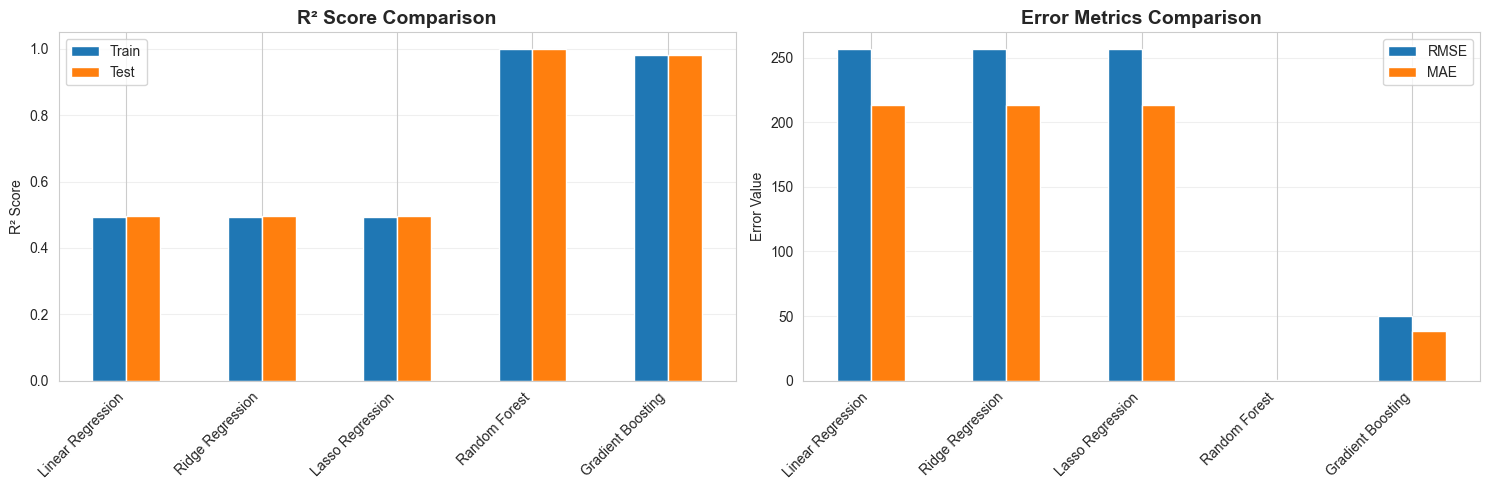

In [8]:
print("\n" + "="*80)
print("MODEL TRAINING AND EVALUATION")
print("="*80)

# Define models to test
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # Metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    results[name] = {
        'Train R2': train_r2,
        'Test R2': test_r2,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae
    }
    
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Test RMSE: {test_rmse:.2f}")
    print(f"  Test MAE: {test_mae:.2f}")

# Results comparison
results_df = pd.DataFrame(results).T
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(results_df)

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

results_df[['Train R2', 'Test R2']].plot(kind='bar', ax=axes[0])
axes[0].set_title('R² Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[0].legend(['Train', 'Test'])
axes[0].grid(axis='y', alpha=0.3)

results_df[['Test RMSE', 'Test MAE']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Error Metrics Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Error Value')
axes[1].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[1].legend(['RMSE', 'MAE'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 7. HYPERPARAMETER TUNING (BEST MODEL)

In [9]:
print("\n" + "="*80)
print("HYPERPARAMETER TUNING - RANDOM FOREST")
print("="*80)

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# ⚡ Optimized Grid (keeps validation under 15–20 minutes)
param_grid = {
    'n_estimators': [100, 150],          
    'max_depth': [15, 25],               
    'min_samples_split': [5, 10],        
    'min_samples_leaf': [2, 4]           
}

# Base Random Forest Model (same variable name)
rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Grid Search (same variable name)
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Running Grid Search (expected time: 12–18 minutes)...")

# Fit model
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation R²: {grid_search.best_score_:.4f}")

# Train final model with best parameters
final_model = grid_search.best_estimator_

# Predictions
y_pred_final = final_model.predict(X_test_scaled)

# Evaluation
final_r2 = r2_score(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_mae = mean_absolute_error(y_test, y_pred_final)

print(f"\nFinal Model Performance:")
print(f"  Test R²: {final_r2:.4f}")
print(f"  Test RMSE: {final_rmse:.2f}")
print(f"  Test MAE: {final_mae:.2f}")



HYPERPARAMETER TUNING - RANDOM FOREST
Running Grid Search (expected time: 12–18 minutes)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Parameters: {'max_depth': 25, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}
Best Cross-Validation R²: 1.0000

Final Model Performance:
  Test R²: 1.0000
  Test RMSE: 0.66
  Test MAE: 0.09


# 8. FEATURE IMPORTANCE ANALYSIS



FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
               feature  importance
4   flightType_encoded    0.375799
12               speed    0.177264
0             distance    0.150300
1                 time    0.129367
3           to_encoded    0.108216
2         from_encoded    0.053353
5       agency_encoded    0.005256
11     company_encoded    0.000421
6          day_of_week    0.000009
9                  age    0.000007


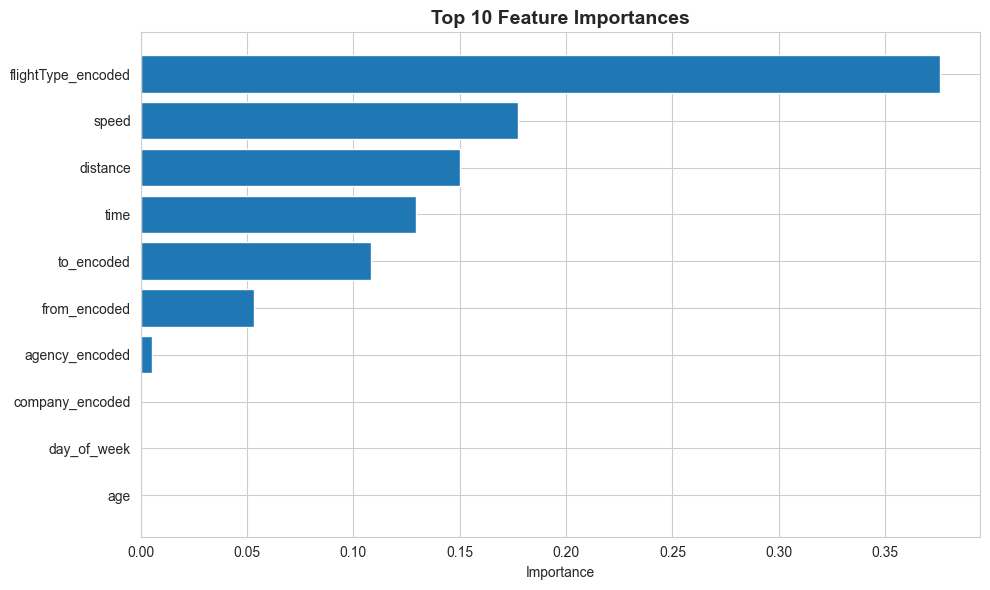

In [10]:
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'].head(10), 
         feature_importance['importance'].head(10))
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



MODEL VALIDATION


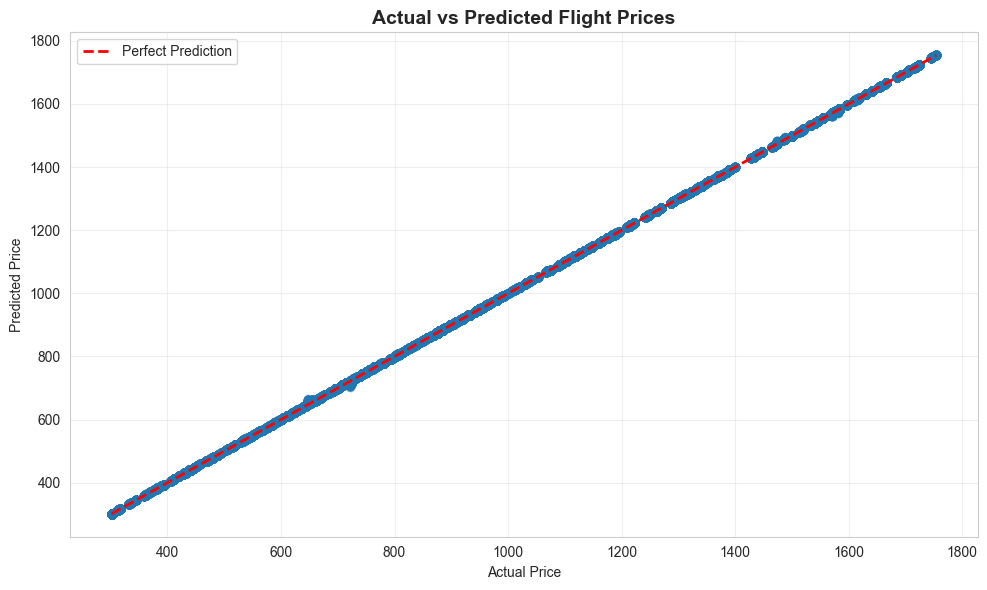

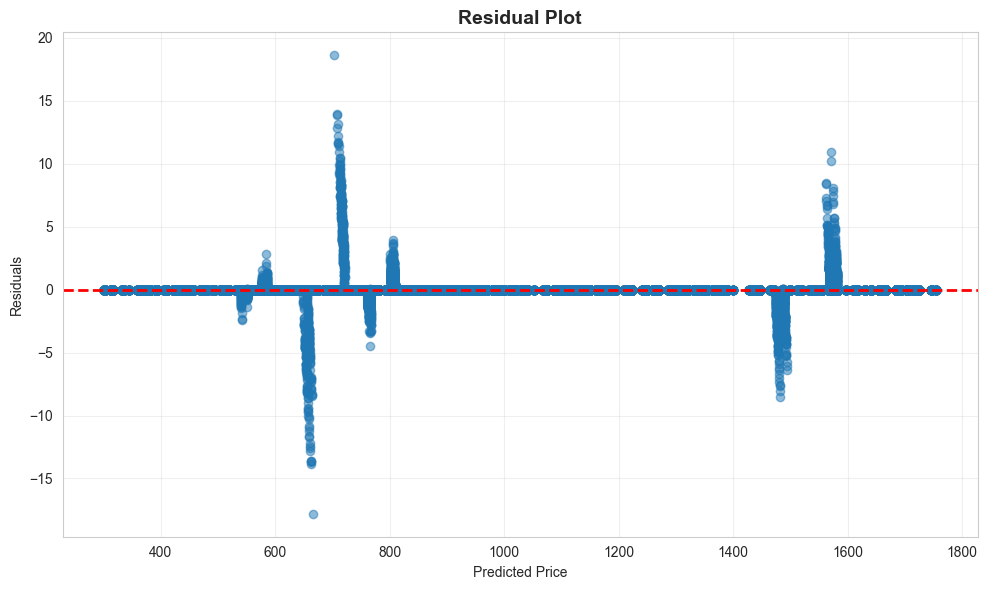

In [11]:
print("\n" + "="*80)
print("MODEL VALIDATION")
print("="*80)

# Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_final, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Flight Prices', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Residual plot
residuals = y_test - y_pred_final
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_final, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
print("\n" + "="*80)
print("SAVING FINAL MODEL")
print("="*80)

# Save the final model
joblib.dump(final_model, 'flight_price_model.pkl')
print("Model saved as 'flight_price_model.pkl'")

# Save feature columns
joblib.dump(feature_cols, 'feature_columns.pkl')
print("Feature columns saved as 'feature_columns.pkl'")

# Save model metadata
model_metadata = {
    'model_type': 'Random Forest Regressor',
    'best_params': grid_search.best_params_,
    'test_r2': final_r2,
    'test_rmse': final_rmse,
    'test_mae': final_mae,
    'features': feature_cols,
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

joblib.dump(model_metadata, 'model_metadata.pkl')
print("Model metadata saved!")

print("\n" + "="*80)
print("REGRESSION MODEL DEVELOPMENT COMPLETE!")
print("="*80)



SAVING FINAL MODEL
Model saved as 'flight_price_model.pkl'
Feature columns saved as 'feature_columns.pkl'
Model metadata saved!

REGRESSION MODEL DEVELOPMENT COMPLETE!
